# Temperature, Sampling, and Decoding Strategies in Oilfield Text Generation

**Notebook 2 of the series.** Notebook 1
(`01_how_a_real_llm_predicts_the_next_token.ipynb`) showed how a real,
locally-run language model turns an oilfield sentence into a full
probability distribution over its vocabulary for the *next* token — using
real logits and real softmax, nothing simulated.

That notebook stopped one step short of a real question: once that
probability distribution exists, how does the model actually end up emitting
*one* token? And how does emitting one token at a time turn into a generated
sentence? This notebook answers that, using the same real model and the same
kind of realistic drilling/completions/intervention sentences.

Still out of scope here (left for later notebooks): attention visualization,
embeddings, hidden-state inspection, and attribution/interpretability
methods. This notebook is about decoding only.

## Learning objectives

1. What is greedy decoding, and how does it relate to `argmax`?
2. What is sampling, and why doesn't the highest-probability token always
   win?
3. What does temperature actually do to a distribution, mathematically —
   and what does it *not* do?
4. What are top-k and top-p (nucleus) sampling, and which tokens survive
   under each?
5. How do these decoding choices combine, one step at a time, to actually
   generate multi-token oilfield text?


## 1. What problem are we investigating?

Notebook 1 ended at the probability distribution:

```
prompt -> tokenizer -> token IDs -> transformer -> logits -> softmax -> probability distribution
```

A probability distribution is not yet a chosen token. Something has to turn
"token A: 33%, token B: 28%, token C: 7%, ..." into a single decision. That
something is a **decoding strategy**:

```
probability distribution -> decoding strategy -> one chosen token
```

And a decoding strategy applied repeatedly, feeding each chosen token back
in as new context, is how a language model generates a whole sentence:

```
prompt -> [ predict distribution -> decode one token -> append it ] -> repeat -> generated text
```

This notebook walks through the two main decoding strategies (greedy,
sampling), the two main knobs used to control sampling (temperature, and
top-k/top-p filtering), and then closes the loop with a small, fully visible
generation loop over real oilfield prompts.


## Installation (run once)

If you already set up the environment for notebook 1, you don't need to do
anything further — this notebook uses the same dependencies. Otherwise,
uncomment and run the cell below once.


In [1]:
# Run this once. After the packages are installed you can leave this commented out.
# %pip install torch transformers accelerate pandas matplotlib numpy
print("If an import in the next cell fails, uncomment and run the pip install line above, then re-run this notebook.")


If an import in the next cell fails, uncomment and run the pip install line above, then re-run this notebook.


## 2. Load the real language model

This is the same model, the same device-detection logic, and the same
reproducibility seeding as notebook 1 — repeated here so this notebook runs
independently, top to bottom, without depending on notebook 1 having been
executed first.


In [2]:
import random
import platform
import sys
from collections import Counter

import numpy as np
import pandas as pd
import torch
import transformers
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PRIMARY_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
FALLBACK_MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"  # used only if the primary model fails to load

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

DTYPE = torch.float16 if DEVICE in ("mps", "cuda") else torch.float32

print(f"Python version:       {sys.version.split()[0]}")
print(f"PyTorch version:      {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")
print(f"Selected device:      {DEVICE}")
print(f"Selected dtype:       {DTYPE}")


Python version:       3.12.13
PyTorch version:      2.14.0
Transformers version: 5.16.1
Selected device:      mps
Selected dtype:       torch.float16


In [3]:
def load_model(model_name: str = PRIMARY_MODEL_NAME):
    '''Load a causal language model and its tokenizer onto the selected device.

    Falls back to FALLBACK_MODEL_NAME if the primary model cannot be loaded,
    and always reports which model actually ended up running.
    '''
    try:
        tok = AutoTokenizer.from_pretrained(model_name)
        mdl = AutoModelForCausalLM.from_pretrained(model_name, dtype=DTYPE)
        mdl.to(DEVICE)
        mdl.eval()
        return tok, mdl, model_name
    except Exception as exc:  # noqa: BLE001 - report and fall back, don't crash the notebook
        print(f"Could not load '{model_name}' ({exc}). Falling back to '{FALLBACK_MODEL_NAME}'.")
        tok = AutoTokenizer.from_pretrained(FALLBACK_MODEL_NAME)
        mdl = AutoModelForCausalLM.from_pretrained(FALLBACK_MODEL_NAME, dtype=DTYPE)
        mdl.to(DEVICE)
        mdl.eval()
        return tok, mdl, FALLBACK_MODEL_NAME


tokenizer, model, MODEL_NAME = load_model()
print(f"\nModel actually loaded and used in this notebook: {MODEL_NAME}")
print(f"Vocabulary size: {model.config.vocab_size:,} tokens")


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]


Model actually loaded and used in this notebook: Qwen/Qwen2.5-1.5B-Instruct
Vocabulary size: 151,936 tokens


## 3. Helper functions from notebook 1

These four functions were built and explained step by step in notebook 1
(tokenization, running the transformer, extracting logits, applying
softmax). We take their correctness as given here and reuse them so this
notebook can focus entirely on decoding.


In [4]:
def tokenize_prompt(prompt: str):
    '''Tokenize a prompt and return (encoded inputs, input_ids tensor, decoded token strings).'''
    encoded = tokenizer(prompt, return_tensors="pt")
    input_ids = encoded["input_ids"][0]
    decoded_tokens = [tokenizer.decode([tid]) for tid in input_ids]
    return encoded, input_ids, decoded_tokens


def get_next_token_distribution(prompt: str):
    '''Run `prompt` through the model and return (input_ids, logits, probabilities) for the next token.'''
    enc = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = model(**enc)
    logits_vec = out.logits[0, -1, :]
    probs_vec = torch.softmax(logits_vec, dim=-1)
    return enc["input_ids"][0], logits_vec, probs_vec


def get_top_tokens(prompt: str, n: int = 15) -> pd.DataFrame:
    '''Return a DataFrame of the top-n next-token candidates for `prompt`, straight from the model.'''
    _, logits_vec, probs_vec = get_next_token_distribution(prompt)
    top_probs, top_ids = torch.topk(probs_vec, n)

    rows = []
    for rank, (tid, prob) in enumerate(zip(top_ids.tolist(), top_probs.tolist()), start=1):
        rows.append({
            "rank": rank,
            "token_id": tid,
            "decoded_token": repr(tokenizer.decode([tid])),
            "logit": logits_vec[tid].item(),
            "probability": prob,
            "probability_percent": f"{prob * 100:.2f}%",
        })
    return pd.DataFrame(rows)


def calculate_entropy(probabilities: torch.Tensor) -> float:
    '''Shannon entropy (natural log, in nats) of a probability distribution tensor.'''
    # Cast to float32 before clamping: in float16 (used on MPS/CUDA), tiny
    # probabilities underflow to exactly 0 at this clamp threshold, and
    # 0 * log(0) produces NaN.
    p = probabilities.float().clamp_min(1e-12)
    return float(-(p * p.log()).sum().item())


## 4. Reference prompt and baseline distribution

We use the same primary sentence from notebook 1 so results are directly
comparable, and compute its real next-token distribution once — every
decoding experiment below reuses this same distribution (or the same
prompt) rather than recomputing something different each time.


In [5]:
PROMPT = "The crew pulled out of hole with the worn PDC bit and prepared to run a new"

_, baseline_logits, baseline_probs = get_next_token_distribution(PROMPT)
baseline_top_tokens = get_top_tokens(PROMPT, n=15)

print(repr(PROMPT))
baseline_top_tokens


'The crew pulled out of hole with the worn PDC bit and prepared to run a new'


,rank,token_id,decoded_token,logit,probability,probability_percent
0,1,2699,' bit',19.906250,0.335205,33.52%
1,2,825,' one',19.718750,0.277832,27.78%
2,3,393,' P',18.406250,0.074829,7.48%
3,4,220,' ',17.312500,0.025055,2.51%
4,5,30546,' drill',17.078125,0.019821,1.98%
5,6,5392,' tool',16.765625,0.014503,1.45%
6,7,22205,' diamond',16.656250,0.013000,1.30%
7,8,11,"','",16.593750,0.012215,1.22%
8,9,1632,' well',15.554688,0.004322,0.43%
9,10,738,' set',15.531250,0.004219,0.42%


## 5. Greedy decoding

**Greedy decoding** always picks the single highest-probability token —
mathematically, `argmax` of the distribution. It's deterministic: the same
prompt always produces the same next token.

Because softmax is a monotonic function (it preserves ordering), the argmax
of the probabilities and the argmax of the raw logits are always the same
token — we verify that directly below rather than assuming it.


In [6]:
def greedy_decode(probabilities: torch.Tensor) -> int:
    '''Return the token ID with the highest probability.'''
    return int(torch.argmax(probabilities).item())


greedy_token_id = greedy_decode(baseline_probs)
greedy_token_id_from_logits = int(torch.argmax(baseline_logits).item())

print(f"Greedy token from probabilities: {greedy_token_id} -> {tokenizer.decode([greedy_token_id])!r}")
print(f"Greedy token from raw logits:    {greedy_token_id_from_logits} -> {tokenizer.decode([greedy_token_id_from_logits])!r}")
assert greedy_token_id == greedy_token_id_from_logits, "argmax over probabilities and over logits should always agree."
assert greedy_token_id == baseline_top_tokens.iloc[0]["token_id"], "Greedy decoding should match rank 1 in the top-tokens table."
print("Sanity checks passed: greedy decoding matches both argmax(logits) and rank 1 of the top-tokens table.")


Greedy token from probabilities: 2699 -> ' bit'
Greedy token from raw logits:    2699 -> ' bit'
Sanity checks passed: greedy decoding matches both argmax(logits) and rank 1 of the top-tokens table.


## 6. Sampling

**Sampling** draws a token at random, weighted by the model's real
probabilities, instead of always taking the top one. A token with 33%
probability will tend to be drawn about a third of the time — not every
time.

We use `torch.multinomial`, seeded with a `torch.Generator` for
reproducibility. Sampling happens on the CPU in float32 for numerical
reliability, regardless of which device the model itself ran on.


In [7]:
def sample_next_token(probabilities: torch.Tensor, seed: int | None = None) -> int:
    '''Draw one token ID at random, weighted by `probabilities`.'''
    probs_cpu = probabilities.detach().to("cpu", dtype=torch.float32)
    generator = torch.Generator(device="cpu")
    if seed is not None:
        generator.manual_seed(seed)
    else:
        generator.seed()
    return int(torch.multinomial(probs_cpu, num_samples=1, generator=generator).item())


sampled_id = sample_next_token(baseline_probs, seed=0)
print(f"One sample (seed=0): {sampled_id} -> {tokenizer.decode([sampled_id])!r}")
print(f"Greedy token, for comparison: {greedy_token_id} -> {tokenizer.decode([greedy_token_id])!r}")


One sample (seed=0): 1863 -> ' Z'
Greedy token, for comparison: 2699 -> ' bit'


### Repeated sampling: does the highest-probability token always win?

We draw 500 independent samples (different seed each time) from the same
real distribution and count how often each token actually comes up. If
sampling is working correctly, each token's *empirical* frequency should
land close to its *true* model probability — but "close" is not "always the
top pick wins every single draw."


In [8]:
N_DRAWS = 500
sampled_ids = [sample_next_token(baseline_probs, seed=i) for i in range(N_DRAWS)]
sample_counts = Counter(sampled_ids)

top8_by_true_prob = baseline_top_tokens.head(8).copy()
top8_by_true_prob["empirical_count"] = [sample_counts.get(tid, 0) for tid in top8_by_true_prob["token_id"]]
top8_by_true_prob["empirical_frequency_percent"] = top8_by_true_prob["empirical_count"] / N_DRAWS * 100

print(f"Unique distinct tokens drawn across {N_DRAWS} samples: {len(sample_counts)}")
top8_by_true_prob[["rank", "decoded_token", "probability_percent", "empirical_count", "empirical_frequency_percent"]]


Unique distinct tokens drawn across 500 samples: 118


,rank,decoded_token,probability_percent,empirical_count,empirical_frequency_percent
0,1,' bit',33.52%,174,34.8
1,2,' one',27.78%,129,25.8
2,3,' P',7.48%,32,6.4
3,4,' ',2.51%,6,1.2
4,5,' drill',1.98%,8,1.6
5,6,' tool',1.45%,4,0.8
6,7,' diamond',1.30%,7,1.4
7,8,"','",1.22%,3,0.6


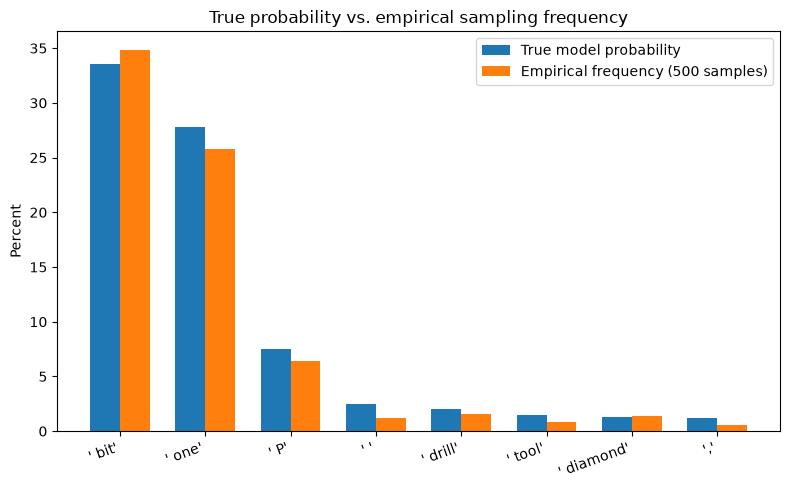

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(top8_by_true_prob))
width = 0.35
true_pct = top8_by_true_prob["probability"] * 100
empirical_pct = top8_by_true_prob["empirical_frequency_percent"]

ax.bar([i - width / 2 for i in x], true_pct, width, label="True model probability")
ax.bar([i + width / 2 for i in x], empirical_pct, width, label=f"Empirical frequency ({N_DRAWS} samples)")
ax.set_xticks(list(x))
ax.set_xticklabels(top8_by_true_prob["decoded_token"], rotation=20, ha="right")
ax.set_ylabel("Percent")
ax.set_title("True probability vs. empirical sampling frequency")
ax.legend()
fig.tight_layout()
plt.show()


**Interpretation:** the two bars for each token should be close but
not identical — that gap is expected sampling noise over a finite number of
draws, not an error. This is also a useful sanity check on our own sampling
code: if empirical frequencies did *not* track true probabilities at all,
that would indicate a bug, not an interesting finding.


## 7. Temperature

**Temperature** rescales logits *before* softmax:

$$P_i = \frac{e^{z_i / T}}{\sum_j e^{z_j / T}}$$

- **Lower temperature (e.g. 0.3)** sharpens the distribution — the model
  becomes more likely to sample its top few candidates.
- **Higher temperature (e.g. 1.5)** flattens the distribution — lower-ranked
  tokens become relatively more likely to be sampled.
- **Temperature does not retrain the model or change its logits.** We reuse
  the exact same `baseline_logits` computed in Section 4 for every
  temperature below — only the post-processing changes.


In [10]:
def apply_temperature(logits: torch.Tensor, temperature: float) -> torch.Tensor:
    '''Return a probability distribution: softmax(logits / temperature). Uses the same logits every time.'''
    scaled_logits = logits.float() / temperature
    return torch.softmax(scaled_logits, dim=-1)


TEMPERATURES = [0.3, 0.7, 1.0, 1.5]
temperature_probs = {T: apply_temperature(baseline_logits, T) for T in TEMPERATURES}

for T in TEMPERATURES:
    top_probs, top_ids = torch.topk(temperature_probs[T], 5)
    print(f"--- Temperature = {T} ---")
    for tid, p in zip(top_ids.tolist(), top_probs.tolist()):
        print(f"  {tokenizer.decode([tid])!r:15s} {p * 100:6.2f}%")


--- Temperature = 0.3 ---
  ' bit'           64.84%
  ' one'           34.70%
  ' P'              0.44%
  ' '               0.01%
  ' drill'          0.01%
--- Temperature = 0.7 ---
  ' bit'           50.00%
  ' one'           38.25%
  ' P'              5.87%
  ' '               1.23%
  ' drill'          0.88%
--- Temperature = 1.0 ---
  ' bit'           33.53%
  ' one'           27.79%
  ' P'              7.48%
  ' '               2.51%
  ' drill'          1.98%
--- Temperature = 1.5 ---
  ' bit'            7.61%
  ' one'            6.71%
  ' P'              2.80%
  ' '               1.35%
  ' drill'          1.15%


In [11]:
reference_token_id = greedy_token_id  # the T=1.0 top token, e.g. ' bit'
reference_token_text = tokenizer.decode([reference_token_id])

temp_summary = pd.DataFrame({
    "temperature": TEMPERATURES,
    f"probability_of_{reference_token_text.strip()!r}_percent": [
        temperature_probs[T][reference_token_id].item() * 100 for T in TEMPERATURES
    ],
    "entropy_nats": [calculate_entropy(temperature_probs[T]) for T in TEMPERATURES],
})
temp_summary


,temperature,probability_of_'bit'_percent,entropy_nats
0,0.3,64.837259,0.674001
1,0.7,50.002903,1.257959
2,1.0,33.525372,3.113424
3,1.5,7.607074,7.650571


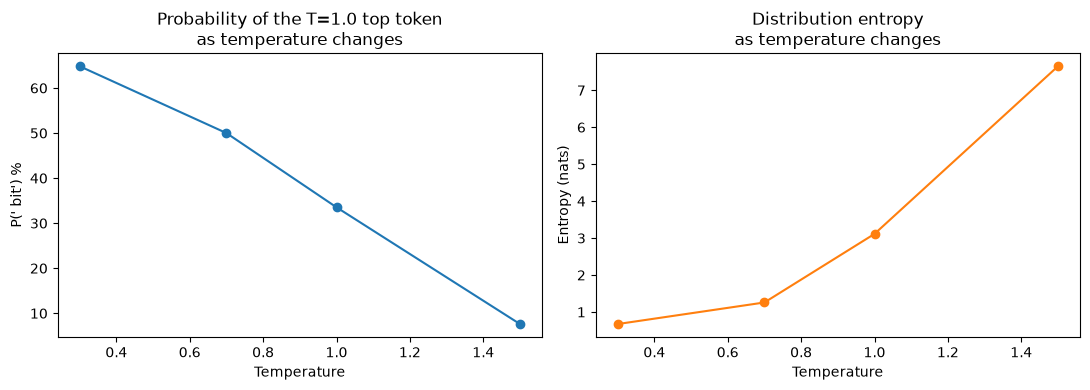

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(temp_summary["temperature"], temp_summary.iloc[:, 1], marker="o")
ax1.set_xlabel("Temperature")
ax1.set_ylabel(f"P({reference_token_text!r}) %")
ax1.set_title("Probability of the T=1.0 top token\nas temperature changes")

ax2.plot(temp_summary["temperature"], temp_summary["entropy_nats"], marker="o", color="tab:orange")
ax2.set_xlabel("Temperature")
ax2.set_ylabel("Entropy (nats)")
ax2.set_title("Distribution entropy\nas temperature changes")

fig.tight_layout()
plt.show()


**Interpretation:** as temperature rises, the top token's probability
share (left chart) should fall and entropy (right chart) should rise —
both computed from the same underlying logits. This is the model's original
next-token scores being reshaped, not the model "changing its mind."


## 8. Temperature and sampling together: diversity

Entropy is a theoretical property of a distribution. Let's check it against
actual sampling behavior: draw 500 samples at a low temperature (0.3) and
500 at a high temperature (1.5) from the same prompt, and count how many
*distinct* tokens actually got drawn at each setting.


In [13]:
diversity_rows = []
for T in [0.3, 1.5]:
    probs_T = temperature_probs[T]
    draws = [sample_next_token(probs_T, seed=i) for i in range(N_DRAWS)]
    diversity_rows.append({
        "temperature": T,
        "unique_tokens_sampled": len(set(draws)),
        "entropy_nats": calculate_entropy(probs_T),
    })

diversity_summary = pd.DataFrame(diversity_rows)
diversity_summary


,temperature,unique_tokens_sampled,entropy_nats
0,0.3,3,0.674001
1,1.5,366,7.650571


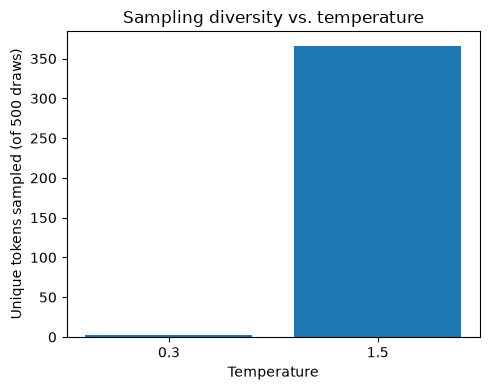

In [14]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(diversity_summary["temperature"].astype(str), diversity_summary["unique_tokens_sampled"])
ax.set_xlabel("Temperature")
ax.set_ylabel(f"Unique tokens sampled (of {N_DRAWS} draws)")
ax.set_title("Sampling diversity vs. temperature")
fig.tight_layout()
plt.show()


**Interpretation:** more unique tokens sampled at higher temperature
is the direct, empirical consequence of the flatter distribution measured
by entropy in Section 7 — not a separate claim about the model being "more
creative."


## 9. Top-k and top-p (nucleus) sampling

Rather than sampling from the full vocabulary, these two strategies first
*filter* the candidate set, then renormalize the remaining probabilities so
they sum to 1 again before sampling:

- **Top-k**: keep only the `k` highest-probability tokens.
- **Top-p (nucleus)**: keep the smallest set of tokens whose cumulative
  probability reaches `p`.

Both are applied here to the real baseline distribution from Section 4.


In [15]:
def top_k_filter(probabilities: torch.Tensor, k: int):
    '''Return (surviving token IDs, their renormalized probabilities) for the top-k tokens.'''
    probs = probabilities.float()
    top_probs, top_ids = torch.topk(probs, k)
    renormalized = top_probs / top_probs.sum()
    return top_ids, renormalized


def top_p_filter(probabilities: torch.Tensor, p: float):
    '''Return (surviving token IDs, their renormalized probabilities) for the smallest set reaching cumulative probability p.'''
    probs = probabilities.float()
    sorted_probs, sorted_ids = torch.sort(probs, descending=True)
    cumulative = torch.cumsum(sorted_probs, dim=-1)
    n_keep = int((cumulative < p).sum().item()) + 1  # include the token that crosses the threshold
    n_keep = min(n_keep, sorted_probs.shape[0])
    kept_ids = sorted_ids[:n_keep]
    kept_probs = sorted_probs[:n_keep]
    renormalized = kept_probs / kept_probs.sum()
    return kept_ids, renormalized


topk_ids, topk_probs = top_k_filter(baseline_probs, k=5)
topp_ids, topp_probs = top_p_filter(baseline_probs, p=0.9)

topk_table = pd.DataFrame({
    "decoded_token": [repr(tokenizer.decode([tid])) for tid in topk_ids.tolist()],
    "original_probability_percent": [baseline_probs[tid].item() * 100 for tid in topk_ids.tolist()],
    "renormalized_probability_percent": (topk_probs * 100).tolist(),
})
print(f"Top-k = 5: {len(topk_ids)} tokens survive.")
display(topk_table)

topp_table = pd.DataFrame({
    "decoded_token": [repr(tokenizer.decode([tid])) for tid in topp_ids.tolist()],
    "original_probability_percent": [baseline_probs[tid].item() * 100 for tid in topp_ids.tolist()],
    "renormalized_probability_percent": (topp_probs * 100).tolist(),
})
print(f"\nTop-p = 0.9: {len(topp_ids)} tokens survive.")
display(topp_table)


Top-k = 5: 5 tokens survive.


,decoded_token,original_probability_percent,renormalized_probability_percent
0,' bit',33.520508,45.746651
1,' one',27.783203,37.916744
2,' P',7.482910,10.212198
3,' ',2.505493,3.419338
4,' drill',1.982117,2.705066



Top-p = 0.9: 133 tokens survive.


,decoded_token,original_probability_percent,renormalized_probability_percent
0,' bit',33.520508,37.235683
1,' one',27.783203,30.862495
2,' P',7.482910,8.312263
3,' ',2.505493,2.783184
4,' drill',1.982117,2.201800
...,...,...,...
128,' extended',0.032043,0.035595
129,' square',0.031781,0.035304
130,' to',0.031543,0.035039
131,' Dick',0.031543,0.035039


**Interpretation:** how many tokens survive top-p=0.9 depends entirely
on how spread out this particular distribution is — a flatter distribution
needs more tokens to reach 90% cumulative probability than a sharply peaked
one. Compare the surviving count above to the entropy value from Section 4's
prompt; that relationship is real, not asserted.


## 10. Putting it together: generating multiple tokens

Everything so far has been a single prediction step. Generation is just this
loop, repeated: predict a distribution for the current text, decode one
token from it, append that token's text, and predict again from the new,
longer text.

The function below does exactly that manually — no `model.generate()`. It
recomputes the full forward pass at every step (no KV-cache), which is fine
for the handful of tokens we generate here on a laptop, but is *not* how
production generation code is written for speed; we call that out
explicitly rather than hide it.


In [16]:
def generate_tokens(prompt: str, n_new_tokens: int, strategy: str = "greedy",
                     temperature: float = 1.0, seed: int | None = None):
    '''Manually repeat single-step next-token prediction n_new_tokens times.

    strategy="greedy" always takes argmax (temperature has no effect on it,
    since temperature scaling preserves the ordering of logits).
    strategy="sample" draws from softmax(logits / temperature).
    '''
    text = prompt
    new_token_reprs = []
    for step in range(n_new_tokens):
        _, logits_vec, probs_vec = get_next_token_distribution(text)
        if strategy == "greedy":
            next_id = int(torch.argmax(logits_vec).item())
        elif strategy == "sample":
            probs_for_sampling = apply_temperature(logits_vec, temperature)
            step_seed = None if seed is None else seed + step
            next_id = sample_next_token(probs_for_sampling, seed=step_seed)
        else:
            raise ValueError(f"Unknown strategy {strategy!r}: use 'greedy' or 'sample'.")
        next_token_text = tokenizer.decode([next_id])
        text += next_token_text
        new_token_reprs.append(repr(next_token_text))
    return text, new_token_reprs


greedy_text, greedy_new_tokens = generate_tokens(PROMPT, n_new_tokens=12, strategy="greedy")
print("GREEDY completion:")
print(greedy_text)
print("\nNew tokens generated, in order:")
print(greedy_new_tokens)


GREEDY completion:
The crew pulled out of hole with the worn PDC bit and prepared to run a new bit. The crew was working on a 100

New tokens generated, in order:
["' bit'", "'.'", "' The'", "' crew'", "' was'", "' working'", "' on'", "' a'", "' '", "'1'", "'0'", "'0'"]


In [17]:
sampled_text, sampled_new_tokens = generate_tokens(
    PROMPT, n_new_tokens=12, strategy="sample", temperature=1.0, seed=42,
)
print("SAMPLED completion (temperature=1.0, seed=42):")
print(sampled_text)
print("\nNew tokens generated, in order:")
print(sampled_new_tokens)


SAMPLED completion (temperature=1.0, seed=42):
The crew pulled out of hole with the worn PDC bit and prepared to run a new PDC bit with adequate filler. However, the casing pul

New tokens generated, in order:
["' P'", "'DC'", "' bit'", "' with'", "' adequate'", "' filler'", "'.'", "' However'", "','", "' the'", "' casing'", "' pul'"]


In [18]:
low_temp_text, _ = generate_tokens(PROMPT, n_new_tokens=12, strategy="sample", temperature=0.3, seed=42)
high_temp_text, _ = generate_tokens(PROMPT, n_new_tokens=12, strategy="sample", temperature=1.5, seed=42)

print("Temperature 0.3:")
print(low_temp_text)
print("\nTemperature 1.5:")
print(high_temp_text)


Temperature 0.3:
The crew pulled out of hole with the worn PDC bit and prepared to run a new bit. The crew was using a 2000

Temperature 1.5:
The crew pulled out of hole with the worn PDC bit and prepared to run a new Peprotec KunSkycretetank behind the roller casing you


**Interpretation:** the greedy completion is fully deterministic — run
it again and it produces the exact same text. The sampled completions are
reproducible *because we fixed a seed*; without a seed they would vary from
run to run. Read the actual sentences above rather than assuming which one
"sounds more natural" — that judgment is a separate, subjective question
from anything the model's probabilities tell us.


## 11. What decoding strategies do — and don't do

We can honestly say, because we computed it directly above:

- greedy decoding always selects the single highest-probability token
- sampling selects a token at random, weighted by the real model
  probabilities
- temperature rescales those probabilities before sampling, and does so
  identically regardless of the prompt's subject matter
- top-k and top-p restrict *which* tokens are eligible to be sampled at all

We should **not** say:

- "higher temperature makes the model more creative or more intelligent" —
  it makes the *sampling distribution* flatter; creativity is a human
  judgment about the resulting text, not a property softmax computes
- "the model is confident" as a synonym for "this token has high
  probability" — probability is a statistical property of one prediction
  step, not a claim about the model's internal certainty in a human sense
- that any of this changes what the model "knows" — every temperature and
  sampling experiment above reused the identical logits from Section 4; only
  the decision procedure on top of them changed

Decoding strategy is a choice made *after* the model has finished computing
a probability distribution. It affects which token is picked; it does not
alter the trained model itself.


## 12. Key lessons

```
prompt
  |
  v
Tokenizer -> token IDs -> Transformer -> logits -> Softmax -> probability distribution
                                                                     |
                                                                     v
                                                          Decoding strategy
                                                    (greedy / temperature+sampling
                                                          / top-k / top-p)
                                                                     |
                                                                     v
                                                              one chosen token
                                                                     |
                                                                     v
                                                    append to text, repeat -> generated text
```

1. Greedy decoding always takes the single highest-probability token —
   deterministic, reproducible, and it matches `argmax` of both the
   probabilities and the raw logits.
2. Sampling draws from the real probability distribution — the highest
   probability token is favored, not guaranteed.
3. Over many draws, empirical sampling frequencies track true model
   probabilities — verified directly above, not assumed.
4. Temperature rescales the same logits before softmax; it does not
   retrain or otherwise change the model.
5. Lower temperature concentrates probability (lower entropy, less
   diversity in repeated sampling); higher temperature spreads it out
   (higher entropy, more diversity).
6. Top-k and top-p restrict the candidate set before sampling, each
   producing a different-sized surviving set depending on how the real
   distribution is shaped.
7. Generation is this whole pipeline, repeated one token at a time —
   nothing more mysterious than notebook 1's single step, looped.
8. None of these decoding choices change what the underlying model
   "knows" — only how a token gets selected from what it already computed.


## 13. Try your own oilfield sentence

Change the values below, then run the cell. It reuses `generate_tokens` from
Section 10 to generate a completion with your chosen strategy and settings.


In [19]:
user_prompt = "The crew ran in hole with the completion assembly and began to"  # <-- change this line
user_strategy = "sample"      # "greedy" or "sample"
user_temperature = 0.8        # only used when user_strategy == "sample"
user_n_new_tokens = 12
user_seed = 7                 # only used when user_strategy == "sample"; set to None for a fresh random draw each run

user_text, user_new_tokens = generate_tokens(
    user_prompt,
    n_new_tokens=user_n_new_tokens,
    strategy=user_strategy,
    temperature=user_temperature,
    seed=user_seed,
)

print(f"Strategy: {user_strategy}" + (f", temperature={user_temperature}" if user_strategy == "sample" else ""))
print(f"\nCompletion:\n{user_text}")
print(f"\nNew tokens generated, in order:\n{user_new_tokens}")

print("\nFirst-step top-10 candidates (before any decoding choice was applied):")
display(get_top_tokens(user_prompt, n=10))


Strategy: sample, temperature=0.8

Completion:
The crew ran in hole with the completion assembly and began to complete the ____ step.
A. 5
B.

New tokens generated, in order:
["' complete'", "' the'", "' ____'", "' step'", "'.\\n'", "'A'", "'.'", "' '", "'5'", "'\\n'", "'B'", "'.'"]

First-step top-10 candidates (before any decoding choice was applied):


,rank,token_id,decoded_token,logit,probability,probability_percent
0,1,4582,' install',18.062500,0.056396,5.64%
1,2,1598,' run',17.796875,0.043243,4.32%
2,3,41740,' assemble',17.609375,0.035858,3.59%
3,4,4828,' raise',17.328125,0.027054,2.71%
4,5,2795,' load',17.265625,0.025421,2.54%
5,6,11893,' lift',16.968750,0.018890,1.89%
6,7,6815,' pull',16.937500,0.018311,1.83%
7,8,4057,' remove',16.906250,0.017746,1.77%
8,9,3271,' move',16.812500,0.016159,1.62%
9,10,975,' work',16.718750,0.014709,1.47%


## 14. Optional exercises

1. In Section 13, switch `user_strategy` to `"greedy"` and compare the
   resulting completion to the sampled one.
2. Try `user_temperature = 0.1` and `user_temperature = 2.0`. How different
   are the completions? How does that relate to the entropy values from
   Section 7?
3. Re-run Section 6's 500-draw sampling experiment (`N_DRAWS`) with a
   different prompt from notebook 1's context experiments (e.g. one of the
   POOH prompts). Does the top token's empirical frequency still track its
   true probability?
4. Change `top_p_filter`'s `p` argument to `0.5` and to `0.99`. How many
   tokens survive in each case?
5. Set `user_seed = None` in Section 13 and run the cell twice in a row.
   Confirm the completion differs between runs — then set a fixed seed
   again and confirm it becomes reproducible.


## 15. Technical appendix

**Model and environment actually used in this run** (printed live, not
hard-coded):


In [20]:
print(f"Model:                {MODEL_NAME}")
print(f"Device:               {DEVICE}")
print(f"Dtype:                {DTYPE}")
print(f"Vocabulary size:      {model.config.vocab_size:,}")
print(f"Python version:       {sys.version.split()[0]}")
print(f"PyTorch version:      {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")
print(f"Random seed:          {SEED}")


Model:                Qwen/Qwen2.5-1.5B-Instruct
Device:               mps
Dtype:                torch.float16
Vocabulary size:      151,936
Python version:       3.12.13
PyTorch version:      2.14.0
Transformers version: 5.16.1
Random seed:          42


**Efficiency note.** `generate_tokens` in Section 10 recomputes the
full forward pass over the whole growing text at every new token. That
keeps every intermediate distribution fully visible and inspectable, which
is the point of this notebook — but it is quadratically wasteful compared to
production generation code, which caches past key/value tensors (a "KV
cache") so each new token only requires one incremental forward step. For
the short completions generated here (a dozen tokens on a small model),
the difference is not noticeable on a laptop; for long-form generation, it
would be.

**Sampling determinism.** All sampling above uses a `torch.Generator` seeded
explicitly, so every result in this notebook is reproducible on your own
machine. Setting `seed=None` anywhere restores true randomness.
